In [239]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

Importamos los datos y los dividimos en conjunto de dev (entrenamiento y validacion) y test:

In [240]:
data = pd.read_csv(r'data/data_preprocessed.csv')
print(data.shape)

(274268, 22)


In [241]:
data_dev, data_test = train_test_split(data, test_size=5000/278725, random_state=42)
data_train, data_val = train_test_split(data_dev, test_size=0.2, random_state=42)

print(data_train.shape)
print(data_val.shape)
print(data_test.shape)

(215477, 22)
(53870, 22)
(4921, 22)


In [242]:
X_train = data_train.drop(columns=['precio_pesos_constantes'])
y_train = data_train['precio_pesos_constantes']
X_val = data_val.drop(columns=['precio_pesos_constantes'])
y_val = data_val['precio_pesos_constantes']
X_test = data_test.drop(columns=['precio_pesos_constantes'])
y_test = data_test['precio_pesos_constantes']

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(215477, 21)
(215477,)
(53870, 21)
(53870,)
(4921, 21)
(4921,)


Tambien si bien algunos datos ya tienen transformaciones aplicadas, buscamos normalizar los datos para que tengan media 0 y desvio 1, para esto usamos la clase StandardScaler de sklearn

In [243]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Creamos un modelo base, y lo evaluamos en el conjunto de datos de train y validación

In [244]:
model = xgb.XGBRegressor(n_estimators=500, 
                         learning_rate=0.05, 
                         max_depth=12, 
                         random_state=42, 
                         eval_metric='rmse', 
                         early_stopping_rounds=10, 
                         gamma=1, 
                         min_child_weight=1,
                         subsample=0.6,
                         colsample_bytree=0.8)

In [245]:
model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=True)

[0]	validation_0-rmse:38310.59045
[1]	validation_0-rmse:36707.31570
[2]	validation_0-rmse:35250.48216
[3]	validation_0-rmse:33759.88054
[4]	validation_0-rmse:32351.65062
[5]	validation_0-rmse:31009.98349
[6]	validation_0-rmse:29731.65426
[7]	validation_0-rmse:28560.97571
[8]	validation_0-rmse:27429.16737
[9]	validation_0-rmse:26380.31557
[10]	validation_0-rmse:25351.84619
[11]	validation_0-rmse:24366.71633
[12]	validation_0-rmse:23469.55378
[13]	validation_0-rmse:22620.57150
[14]	validation_0-rmse:21799.05824
[15]	validation_0-rmse:21039.34774
[16]	validation_0-rmse:20307.25146
[17]	validation_0-rmse:19636.07809
[18]	validation_0-rmse:19006.44230
[19]	validation_0-rmse:18372.22766
[20]	validation_0-rmse:17788.91382
[21]	validation_0-rmse:17255.67580
[22]	validation_0-rmse:16762.42878
[23]	validation_0-rmse:16293.99201
[24]	validation_0-rmse:15824.37053
[25]	validation_0-rmse:15400.51126
[26]	validation_0-rmse:15010.42889
[27]	validation_0-rmse:14622.15579
[28]	validation_0-rmse:14265.9

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

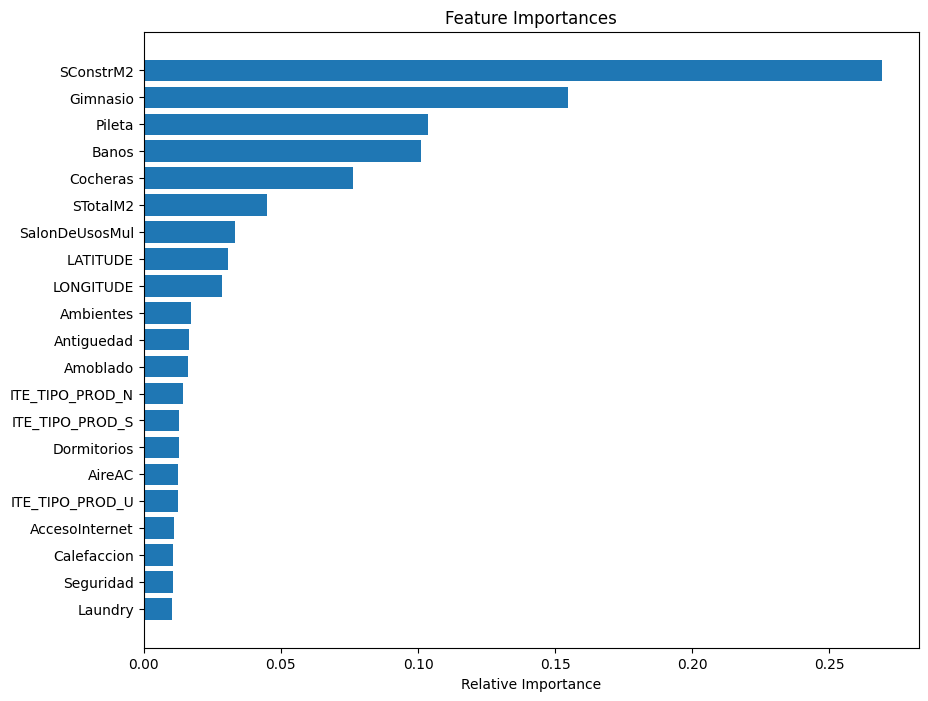

In [246]:
#ver la feature importance de nuestro modelo
importances = model.feature_importances_
indices = importances.argsort()[::-1]
features = X_train.columns

plt.figure(figsize=(10, 8))
plt.title('Feature Importances')
plt.barh(range(X_train.shape[1]), importances[indices], align='center')
plt.yticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

In [247]:
y_train_pred = model.predict(X_train_scaled)
rmse = root_mean_squared_error(y_train, y_train_pred)
print('RMSE train:', rmse)
r2 = r2_score(y_train, y_train_pred)
print('R2 train:', r2)

RMSE train: 5637.405133781226
R2 train: 0.9808476784028963


In [248]:
y_val_pred = model.predict(X_val_scaled)
rmse = root_mean_squared_error(y_val, y_val_pred)
print('RMSE val:', rmse)
r2 = r2_score(y_val, y_val_pred)
print('R2 val:', r2)

RMSE val: 7672.975164287434
R2 val: 0.9632850022929206


Ahora que tenemos un modelo base, intenetamos mejorar el rendimiento del modelo. Para ello, vamos a comenzar por buscar los hiperparámetros óptimos para el modelo (los que consideramos mas importantes):

In [249]:
# saco hiperparametros optimos
param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [7, 9, 12],
    'subsample': [0.8, 1.0],
    'gamma': [0, 1, 3],
    'min_child_weight': [1, 3]
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42), param_grid=param_grid, cv=2, scoring='neg_root_mean_squared_error', verbose=2)
grid_search.fit(X_train_scaled, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best RMSE: {grid_search.best_score_}')

Fitting 2 folds for each of 324 candidates, totalling 648 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   2.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   2.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=1.0; total time=   2.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_est

Una vez que tengamos los hiperparámetros óptimos, vamos a hacer cross-validation para evaluar el rendimiento del modelo de una manera más robusta:

In [250]:
best_model = grid_search.best_estimator_
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Validacion cruzada en conjunto de train
cv_score_train_rmse = cross_val_score(best_model, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')
cv_score_train_r2 = cross_val_score(best_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'Cross-validation RMSE (5-fold): {cv_score_train_rmse}')
print(f'Promedio RMSE de CV: {-cv_score_train_rmse.mean()}')
print(f'Cross-validation R2 (5-fold): {cv_score_train_r2}')
print(f'Promedio R2 de CV: {cv_score_train_r2.mean()}')

#Validacion cruzada en conjunto de validacion
cv_score_val_rmse = cross_val_score(best_model, X_val_scaled, y_val, cv=kf, scoring='neg_root_mean_squared_error')
cv_score_val_r2 = cross_val_score(best_model, X_val_scaled, y_val, cv=kf, scoring='r2')
print(f'Cross-validation RMSE (5-fold): {cv_score_val_rmse}')
print(f'Promedio RMSE de CV: {-cv_score_val_rmse.mean()}')
print(f'Cross-validation R2 (5-fold): {cv_score_val_r2}')
print(f'Promedio R2 de CV: {cv_score_val_r2.mean()}')

Cross-validation RMSE (5-fold): [-7660.97715875 -7511.71559215 -8464.64958508 -7763.28218091
 -7614.16304555]
Promedio RMSE de CV: 7802.957512490345
Cross-validation R2 (5-fold): [0.96488489 0.96586933 0.95820236 0.9638895  0.96350702]
Promedio R2 de CV: 0.9632706189896119
Cross-validation RMSE (5-fold): [-11969.52785518 -11863.4386908  -12579.66950139 -12275.55252183
 -11775.53092562]
Promedio RMSE de CV: 12092.74389896496
Cross-validation R2 (5-fold): [0.91356464 0.9116685  0.90191119 0.90563729 0.91090544]
Promedio R2 de CV: 0.9087374104445857


Finalmente, simulamos un set de test para evaluar el rendimiento del modelo en datos no vistos

In [251]:
y_test_pred = best_model.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_test_pred)
print('RMSE test:', rmse)
r2 = r2_score(y_test, y_test_pred)
print('R2 test:', r2)

RMSE test: 6943.798346453657
R2 test: 0.9678606687915812


Por ultimo, nos guardamos los datos en nuestro archivo de salida

In [252]:
predictions_df = pd.DataFrame({'id': X_test['id_grid'], 'predicted_price': y_test_pred})
predictions_df.to_csv('predictions.csv', index=False)
print("Predicciones guardadas en 'predictions.csv'")

KeyError: 'id_grid'